# Agglomorative Clustering
* Hierarchal clustering is a group of clustering algorithms which, unlike K-Means clustering, has no predefined number of clusters. Instead it builds nested clusters by merging or splitting the similar clusters consecutively, usually grouping the two most similar clusters first. This is commonly viewed using a dendrogram which displays a tree-like graph showing the structure of the clusters. 

* Agglomerative clustering is a form of Hierarchal Clustering which uses a ‘bottom up’ approach. This means that each datapoint begins as its own individual cluster, and similar clusters are iteratively merged together until the entire dataset is one single cluster. This merging is based on the linkage criteria, which determines the closeness of each cluster. 

* In this analysis, we create two distinct agglomerative clustering models, on a dataset of 1,925 Irish property listings, using the same features used in our K-Means model (Rent_Price, Land_Price, Average_Value_County, Population of County, Average_Value_Bedroom_Count and Net_Income). By applying a hierarchical clustering model to the data, we can assess whether the three-tiered pricing strategy for our property development business is justified by viewing the structure of the current housing market and assessing the similarities between property types. 


# 1. Imports

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.pipeline import Pipeline
import joblib
from sklearn.decomposition import PCA


In [7]:
# reading and viewing dataset
df = pd.read_csv('Data_with_class.csv')
df.head()


,Unnamed: 0.1,Unnamed: 0,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Average_Value_County,Rent_To_Land_Ratio,Average_Value_Bedroom_Count,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,0,0,Standard,Four plus bed,Carlow,1397.92,17417,61968,976.857368,0.080262,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
1,1,1,Standard,Four plus bed,Carlow,1323.98,17417,61968,976.857368,0.076017,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
2,2,2,Standard,All bedrooms,Carlow,1060.03,17417,61968,976.857368,0.060862,1029.973333,86.53,147.83,25.62,33.55,7.19,53953
3,3,3,Standard,Three bed,Carlow,1028.83,17417,61968,976.857368,0.059070,1002.910000,86.53,147.83,25.62,33.55,7.19,53953
4,4,4,Standard,All bedrooms,Carlow,1017.06,17417,61968,976.857368,0.058395,1029.973333,86.53,147.83,25.62,33.55,7.19,53953


# 2. Pre-Processing and Feature Selection 

To keep this model consistent with our k-means model, the same features were selected for the agglomerative clustering models, other variables were excluded from the model for the same reasons as previosuly stated:
* Rent_Price 
* Land_Price 
* Population of County 
* Average_Value_County 
* Net_Income 
* Average_Value_Bedroom_Count 

Furthermore, in this model the and encoded variable for number of bedrooms was initally used for exploritory analysis, however it was later removed for comparison purposes. 


In [8]:

# Encoding Bedroom 
le =  LabelEncoder()
df['Number_of_Bedrooms_ENC'] = le.fit_transform(df['Number of Bedrooms'])
# Feature selection
features = ["Rent_Price","Land_Price","Population of County","Average_Value_County","Net_Income","Average_Value_Bedroom_Count"]

data = df[features].dropna()

data.head()



,Rent_Price,Land_Price,Population of County,Average_Value_County,Net_Income,Average_Value_Bedroom_Count
0,1397.92,17417,61968,976.857368,53953,1360.950000
1,1323.98,17417,61968,976.857368,53953,1360.950000
2,1060.03,17417,61968,976.857368,53953,1029.973333
3,1028.83,17417,61968,976.857368,53953,1002.910000
4,1017.06,17417,61968,976.857368,53953,1029.973333


In [9]:
# Scaling 
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), features)
])

# df_scaled used separately for visualisations only
df_scaled = preprocessor.fit_transform(data[features])

joblib.dump(df_scaled, 'X_scaled_data.pkl')


['X_scaled_data.pkl']

# 3. Hyper-parameter selection - Linkage and Number of Clusters

As discussed ealrier the linkage criteria determines how the clusters will be merged by defining the distance between the clusters. This is the main choice of hyperparemters for an agglomerative clustering model, and the linkage choice will change the structure of the hierarchy.  The four main linkage types are as follows: 

* Ward linkage: Seeks to minimise the sum of squared differences within all clusters. It aims to minimise variance between each cluster when merging.  

* Complete linkage:  Seeks to minimise the maximum distance between observations of pairs of clusters.

* Average linkage:  Seeks to minimise the average of the distances between all observations of pairs of clusters.

* Single linkage:  Seeks to minimise the distance between the closest observations of pairs of clusters.

[{'Linkage': 'ward', 'Number of Clusters': 2, 'Silhouette score': 0.6009},
 {'Linkage': 'ward', 'Number of Clusters': 3, 'Silhouette score': 0.5231},
 {'Linkage': 'ward', 'Number of Clusters': 4, 'Silhouette score': 0.4845},
 {'Linkage': 'ward', 'Number of Clusters': 5, 'Silhouette score': 0.4892},
 {'Linkage': 'complete', 'Number of Clusters': 2, 'Silhouette score': 0.2805},
 {'Linkage': 'complete', 'Number of Clusters': 3, 'Silhouette score': 0.4841},
 {'Linkage': 'complete', 'Number of Clusters': 4, 'Silhouette score': 0.4043},
 {'Linkage': 'complete', 'Number of Clusters': 5, 'Silhouette score': 0.3916},
 {'Linkage': 'average', 'Number of Clusters': 2, 'Silhouette score': 0.6011},
 {'Linkage': 'average', 'Number of Clusters': 3, 'Silhouette score': 0.5757},
 {'Linkage': 'average', 'Number of Clusters': 4, 'Silhouette score': 0.5311},
 {'Linkage': 'average', 'Number of Clusters': 5, 'Silhouette score': 0.5268},
 {'Linkage': 'single', 'Number of Clusters': 2, 'Silhouette score': 0.60

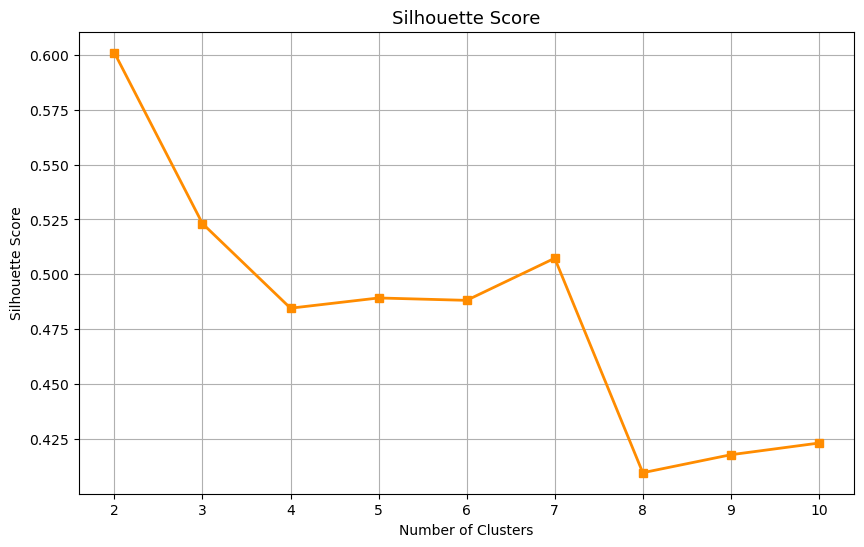

In [10]:
# Displaying the silhouette scores for different linkage methods and cluster numbers (2-5 clusters)
linkages = ['ward', 'complete', 'average', 'single']
cluster_range = range(2, 6)
results = []

for linkage_type in linkages:
    for n_clusters in cluster_range:
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_type)
        labels = model.fit_predict(df_scaled)
        sil_score = silhouette_score(df_scaled, labels)
       

        results.append({
            
            'Linkage': linkage_type,
            'Number of Clusters': n_clusters,
            'Silhouette score': round(sil_score, 4),
        })


display(results)


# Plotting Silhoutte Scores for different cluster numbers (2-10 clusters) 
h_range = range(2, 11)
scores = []
for n_clusters in h_range:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(h_range, scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score', fontsize=13)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

The following table summarises the comparison of silhouette scores between the different linkage types:

| Clusters | Ward Linkage | Average Linkage | Single Linkage | Complete Linkage |
| :--- | :---: | :---: | :---: | :---: |
| 2 | 0.6009 | 0.6011 | 0.6009 | 0.2805 |
| 3 | 0.5231 | 0.5757 | 0.5757 | 0.4841 |
| 4 | 0.4845 | 0.5311 | 0.4443 | 0.4043 |
| 5 | 0.4892 | 0.5268 | 0.5038 | 0.3916 |

Comparing all linkage types,  'average' returns the highest silhoutte score for 2 clusters. However this is a very minimal increse (0.002) and it doesn't outright suggest the use of this hyperperameter. 'Average' minimises the average of the distances between all observations of pairs of clusters and therefore can can tend to create uneven cluster sizes. Ward gives a more regular sized set of clusters and in our business context we want to create distinct price tiers with an similar number of hosues in each.Therefore this hyper-parameter was chosen. The highest silhouette score is returned for 2 clusters for each of these linkage types. In the next section will examine the dendrogram produced when using ward linkage.  

## Dendrogram 


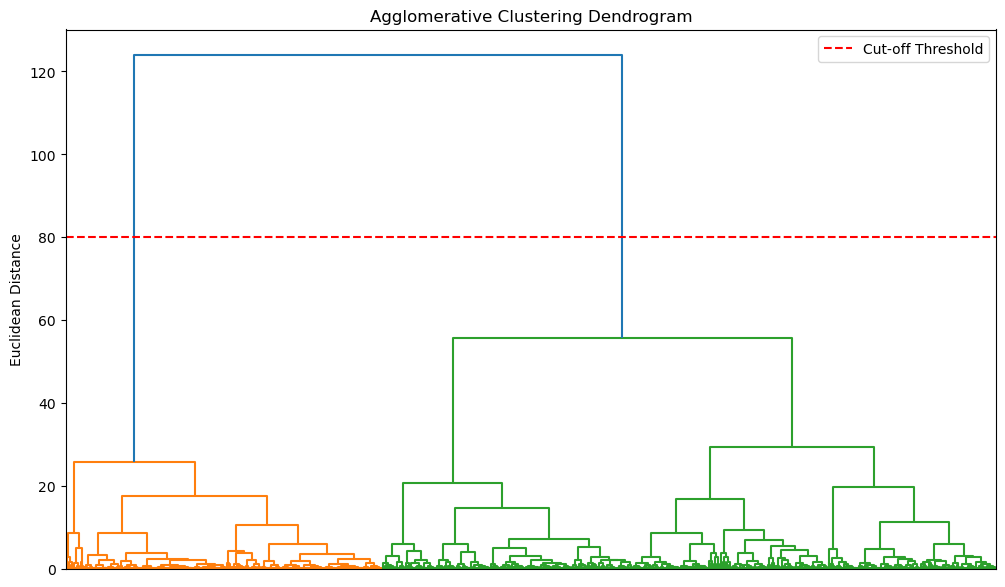

In [11]:

# Plotting the dendrogram 
df_dendrogram = linkage(df_scaled, method='ward')
plt.figure(figsize=(12, 7)) 
dendrogram(df_dendrogram, truncate_mode = None, no_labels=True)
plt.title('Agglomerative Clustering Dendrogram')
plt.ylabel('Euclidean Distance')
plt.axhline(y=80, color='red', linestyle='--', label='Cut-off Threshold')
plt.legend()
plt.show()


# 4. Dendrogram Analysis:
A dendrogram shows us the structure of the clusters in a tree-like visualisation. It visualises the similarity betwen points and where each cluster is merged. Here there are three disticnt types. By just looking at the structure of the dendrogram, we can see the hierarchal structure of the irish rental market. There appears to be main 3 groups present here, visualised by the three rising clades.  The left cade is more disticnt than the two on the right which look to be sharing similarites. 

In hierarchal clustering we do not define the number of clusters, instead the model will define it for us. The dendrogram can help identify the optimal number of clusters. On the Y axis the Euclidean distance is measured, which represents the similarity in clusters i.e. the higher the Euclidean disatance, the more dissimilar two clusters are. The optimal number of clusters is typically defined by the ommitting the cluster with the largest Euclidean distance. On the dendrogram this is done by asessing where the largest vertical gap occurs, and cutting-off the clusters at this point. In the dendrogram above we can see the largest Euclidean distance is between 58 and 122 sugeesting this as the cut-off point, and 2 clusters as the optimal number of clusters represented as orange and green clusters on the graph.  However, the arguement can be made for three distinct clusters being present here, as there is quite a signficant gap between 35 and 58 splitting the green cluster into two. For this reason, create two agglomerative models were created for analysis, one with n_clusters = 3 and one with n_clusters = 2.

# 5. Model with Two Clusters

In [12]:
# Creating the Hierarchical Model with 2 clusters
agglomerative_model_2_clusters = AgglomerativeClustering(n_clusters= 2 , linkage='ward')
data['Agglomerative_Cluster_2'] = agglomerative_model_2_clusters.fit_predict(df_scaled)

joblib.dump(agglomerative_model_2_clusters, 'agglomerative_model_2_clusters.pkl')


['agglomerative_model_2_clusters.pkl']

In [14]:
summary = data.groupby('Agglomerative_Cluster_2').mean().round(2)
print(summary)

                         Rent_Price  Land_Price  Population of County  \
Agglomerative_Cluster_2                                                 
0                            996.92    14785.57             213944.03   
1                           1842.65    18395.00            1458154.00   

                         Average_Value_County  Net_Income  \
Agglomerative_Cluster_2                                     
0                                      996.92    57014.54   
1                                     1842.65    70886.00   

                         Average_Value_Bedroom_Count  
Agglomerative_Cluster_2                               
0                                             996.92  
1                                            1842.65  


In [13]:
pd.crosstab(data['Agglomerative_Cluster_2'], df['Price_Category'])


Price_Category,Budget,Luxury,Standard
Agglomerative_Cluster_2,,,
0,482,37,751
1,0,444,211


The table below shows the mean feature values for each cluster created in the agglomerative model using 2 clusters.

| Feature | Cluster 0 | Cluster 1 |
|:---|:---:|:---:|
| **Rent_Price (€)** | 996.92 | 1,842.65 |
| **Land_Price (€)** | 14,785.57 | 18,395.00 |
| **Population of County** | 213,944.03 | 1,458,154.00 |
| **Average_Value_County (€)** | 996.92 | 1,842.65 |
| **Net_Income (€)** | 57,014.54 | 70,886.00 |
| **Average_Value_Bedroom_Count** | 996.92 | 1,842.65 |


**Key Observations:**


**Cluster 0 (Rest of Country):** 
Cluster 0 contains a much lower value across all features here. The average rent price is almost €1000 euro less than cluster 1, indicating a huge difference in the rent paid on properties in each cluster. A much lower average net income is earned by households in this cluster (€57,014 vs €70,886), confirming the link between income and rent. 

**Cluster 1 (Dublin):**
Cluster 1 represents much higher value properties, The mean Population of County in this cluster is Dublin's exact population, revealing this cluster likely only contains properties in Dublin. This indicates that the inclusion of a datapoint within this cluster almost entirely hinges on whether that property is in Dublin or not. 

**Business Implication:**
These clusters are highly distinct from each other, revealing two strong separate types of properties. The biggest insight gained here is that cluster 1 is likely entirely composed of Dublin properties suggesting two different pricing strategies: one for properties in Dublin, and one for properties outside of it. It also suggests that Dublin and the rest of the country should be viewed as seperate economic entities, and analysis of the properties in the rest of the country should be done seperatly in the future to ensure differences in these properties is revealed.



# 6. Model with Three Clusters

In [ ]:
# Creating the Hierarchical Model with 3 clusters 
agglomerative_model_3_clusters = AgglomerativeClustering(n_clusters=3, linkage='ward')
data['Agglomerative_Cluster_3'] = agglomerative_model_3_clusters.fit_predict(df_scaled)

joblib.dump(agglomerative_model_3_clusters, 'agglomerative_model_3_clusters.pkl')

joblib.dump()

['agglomerative_model_3_clusters.pkl']

In [ ]:
cluster_summary = data.groupby('Agglomerative_Cluster_3')[features].mean().round(2)
display(cluster_summary)
print(cluster_summary)

,Rent_Price,Land_Price,Population of County,Average_Value_County,Net_Income,Average_Value_Bedroom_Count
Agglomerative_Cluster_3,,,,,,
0,1094.26,17440.04,264714.21,1094.26,59815.89,1094.26
1,1842.65,18395.00,1458154.00,1842.65,70886.00,1842.65
2,855.62,10931.97,140239.06,855.62,52947.71,855.62


                         Rent_Price  Land_Price  Population of County  \
Agglomerative_Cluster_3                                                 
0                           1094.26    17440.04             264714.21   
1                           1842.65    18395.00            1458154.00   
2                            855.62    10931.97             140239.06   

                         Average_Value_County  Net_Income  \
Agglomerative_Cluster_3                                     
0                                     1094.26    59815.89   
1                                     1842.65    70886.00   
2                                      855.62    52947.71   

                         Average_Value_Bedroom_Count  
Agglomerative_Cluster_3                               
0                                            1094.26  
1                                            1842.65  
2                                             855.62  


In [28]:
pd.crosstab(data['Agglomerative_Cluster_3'], df['Price_Category'])


Price_Category,Budget,Luxury,Standard
Agglomerative_Cluster_3,,,
0,0,444,211
1,174,32,552
2,308,5,199


# Cluster Analysis
The table below shows the mean feature values for each cluster created in the agglomerative model using 3 clusters.

|  | Cluster 0 | Cluster 1 | Cluster 2 |
| :--- | :---: | :---: | :---: |
| **Rent Price** | 1,094.26 | 1,842.65 | 855.62 |
| **Land Price** | 17,440.04 | 18,395.00 | 10,931.97 |
| **Population** | 264,714.21 | 1,458,154.00 | 140,239.06 |
| **Average Value (County)** | 1,094.26 | 1,842.65 | 855.62 |
| **Net Income** | 59,815.89 | 70,886.00 | 52,947.71 |
| **Avg Value/Bedroom** | 1,094.26 | 1,842.65 | 855.62 |




**Key Observations:**
The results of agglomerative clustering using n_clusters = 3 is almost identical to our k-means model results. 

**Cluster 0 : Standard**
Cluster 1 represents our standard price tier, sitting between cluster 0 and 1 across all features, acting as a typical Irish property. However, these mean values are not much larger those from Cluster 2, indicating a simialrity between these two clusters.  

**Cluster 1 : Luxury**
Cluster 0 has the highest values across all features. The mean Rent_Price of €1,843 is by far the highest across all clusters, as well as  Net_Income Average_Value_County,This strongly aligns with our luxury price tier. The key difference is here is the Dublin effect iss occuring here once again. Cluster 0 contains a population of 1,458,154 which is Dublin's popualtion. 

**Cluster 2 : Budget**
Cluster 2 has the lowest values across every feature, with a mean
Rent_Price of €854 and the lowest Land_Price of €10,953 as well as the lowest Net_Income of €52,975 levels. 

**Business Implication:**
While these clustering methods use different mathematical logic, the ward linkage and k-means algorithms reveal a clear and stable 3-tiered pricing system as discussed in the k-means section. The consistency of the three-cluster results across methods is highly encouraging for our hypothesised  luxury, standard, and budget pricing tiers.




# 7.  Comparing Agglomerative and K-Means Model

In [26]:
kmeans_pipeline = joblib.load('kmeans_model.pkl')
data['KMeans_model'] = kmeans_pipeline.predict(df)

| Algorithm | Silhouette Score | Clusters |
|---|---|---|
| K Means | 0.5231 | 3 |
| Agglomerative_2 | 0.6 | 2 |
| Agglomerative_3 |  0.56| 3 |

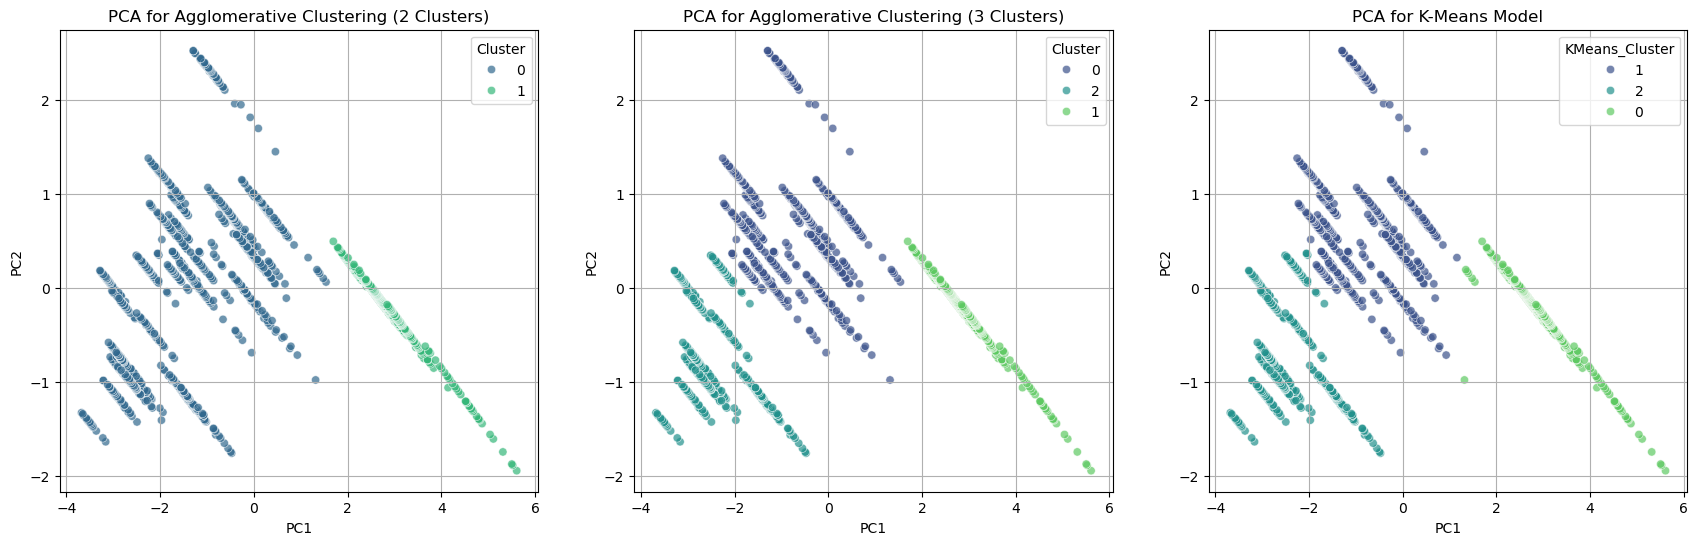

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# PCA for 2 clusters
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = data['Agglomerative_Cluster_2'].astype(str)

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7, ax=axes[0])
axes[0].set_title(f'PCA for Agglomerative Clustering (2 Clusters)')
axes[0].grid(True)

#PCA for 3 clusters
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = data['Agglomerative_Cluster_3'].astype(str)

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title(f'PCA for Agglomerative Clustering (3 Clusters)')
axes[1].grid(True)


# PCA for K-Means 
df_pca['KMeans_Cluster'] = data['KMeans_model'].astype(str)

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis', alpha=0.7, ax=axes[2])
axes[2].set_title(f'PCA for K-Means Model')
axes[2].grid(True)

plt.show()



**Key Observations:**


**Optimal Seperation:**
For all models, the clusters are divided along the horizontal axis, indicating that PC1 is the primary driver of cluster separation. PC1 once again likely reflects high value factors like Rent_Price and Population. In all three models the 'Dublin cluster' is clearly separated along the horizontal axis. However, when using 3 clusters the separation isn't as distinct. While the clusters are moderately seperated in our models with 3 clusters, using 2 clusters creates an increased separation between clusters. The main difference in our k-means model with 3 clusters and our agglomerative model with 3 clusters, is within our k-means model there is a small amount of crossover between our 'luxury' and 'standard' clusters indicating less separation. This is reflected in the silhouete score of 0.56 compared to 0.56. Out of all models the Agglomerative Model with 2 clusters returns the highest silhouette score (0.6) indicating it returns the most well-defined and separated cluster. For this reason we believe this is the optimal model for our business to use, even if it does not line up with our 3-tiered pricing system. 

**Business Impact:**
 Overall, a two-cluster agglomerative model is likely the most suitable for this data revealing the need for our business to treat the Dublin rental market entirely different to the rest of the country. Overall, this spurs further investigation into the drivers of rental prices within these two clusters, and on collection of more data this model should be re-deployed to employ this strategy. Although any use in a business scenario the model should be used a tool alongside employees with expert domain knowledge to ensure active over-sight of the model's decision-making.



